<a href="https://colab.research.google.com/github/szabeebzaliz7-a11y/Datascience-And-Gen-AI/blob/main/Assignment_10_RNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building a SimpleRNN Model for Weather Temperature Prediction

Objective

The goal of this assignment is to design, implement, and evaluate a Recurrent Neural Network
(RNN) model (using SimpleRNN) to forecast the next day’s temperature based on past weather
data.

Use the Daily Weather Dataset

● Example: Daily Weather Dataset – Kaggle
● Key Features:
○ Date
○ Temperature (target variable)
○ Humidity
○ Wind Speed
○ Pressure (optional)

Tasks

Part A: Data Understanding and Preprocessing
1. Load the dataset and explore:
○ Display first 10 rows.
○ Plot temperature trends over time.
○ Check for missing values.

2. Preprocess the data:
○ Handle missing values (impute/remove).
○ Normalize values using MinMaxScaler (so RNN converges faster).
○ Create input sequences:
■ Use past 7–14 days’ weather data (temperature, humidity, wind speed)
as input.
■ Target: next day’s temperature.
○ Split dataset into train, validation, and test sets.

In [16]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras import layers,models
from kagglehub import KaggleDatasetAdapter


In [17]:

path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-dataset' dataset.
Path to dataset files: /kaggle/input/weather-dataset


In [18]:
os.listdir(path)

['weatherHistory.csv']

In [19]:
data_path=os.path.join(path,"daily_weather.csv")

In [20]:
data_path

'/kaggle/input/weather-dataset/daily_weather.csv'

In [21]:
train_path=os.path.join(path,'daily_weather.csv')
test_path=os.path.join(path,'daily_weather.csv')
pred_path=os.path.join(path,'daily_weather.csv')
print(train_path)
print(test_path)
print(pred_path)

/kaggle/input/weather-dataset/daily_weather.csv
/kaggle/input/weather-dataset/daily_weather.csv
/kaggle/input/weather-dataset/daily_weather.csv


In [22]:
train_path = os.path.join(path, 'weatherHistory.csv')
test_path = os.path.join(path, 'weatherHistory.csv')
pred_path = os.path.join(path, 'weatherHistory.csv')

train_ds=pd.read_csv(train_path)
test_ds=pd.read_csv(test_path)
pred_ds=pd.read_csv(pred_path)

In [36]:
train_ds

,Formatted Date,Summary,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-03-31 22:00:00+00:00,Partly Cloudy,0.506975,0.523486,0.89,0.221130,0.699164,0.983,0.0,0.970135,Partly cloudy throughout the day.
1,2006-03-31 23:00:00+00:00,Partly Cloudy,0.505085,0.521084,0.86,0.223399,0.721448,0.983,0.0,0.970613,Partly cloudy throughout the day.
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,0.505445,0.553144,0.89,0.061523,0.568245,0.929,0.0,0.970909,Partly cloudy throughout the day.
3,2006-04-01 01:00:00+00:00,Partly Cloudy,0.487805,0.501947,0.83,0.220877,0.749304,0.983,0.0,0.971358,Partly cloudy throughout the day.
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,0.495365,0.517356,0.83,0.172970,0.721448,0.983,0.0,0.971454,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 17:00:00+00:00,Partly Cloudy,0.774998,0.801259,0.43,0.172214,0.086351,1.000,0.0,0.969399,Partly cloudy starting in the morning.
96449,2016-09-09 18:00:00+00:00,Partly Cloudy,0.751778,0.779886,0.48,0.158094,0.055710,0.966,0.0,0.970164,Partly cloudy starting in the morning.
96450,2016-09-09 19:00:00+00:00,Partly Cloudy,0.710557,0.741944,0.56,0.140696,0.083565,1.000,0.0,0.970642,Partly cloudy starting in the morning.
96451,2016-09-09 20:00:00+00:00,Partly Cloudy,0.702187,0.734239,0.60,0.164902,0.055710,1.000,0.0,0.970919,Partly cloudy starting in the morning.


In [35]:
train_ds.columns

Index(['Formatted Date', 'Summary', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [23]:
print('First 10 rows of train_ds:')
print(train_ds.head(10))

First 10 rows of train_ds:
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   
5  2006-04-01 05:00:00.000 +0200  Partly Cloudy        rain         9.222222   
6  2006-04-01 06:00:00.000 +0200  Partly Cloudy        rain         7.733333   
7  2006-04-01 07:00:00.000 +0200  Partly Cloudy        rain         8.772222   
8  2006-04-01 08:00:00.000 +0200  Partly Cloudy        rain        10.822222   
9  2006-04-01 09:00:00.000 +0200  Partly Cloudy        rain        13.772222   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889     

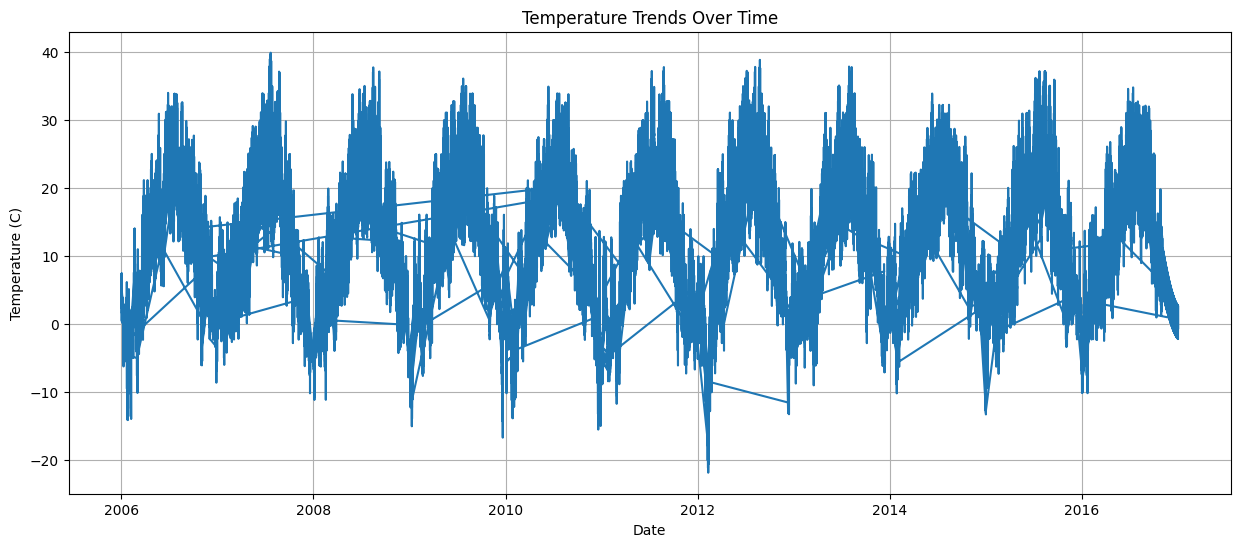

In [24]:
train_ds['Formatted Date'] = pd.to_datetime(train_ds['Formatted Date'], utc=True)
plt.figure(figsize=(15, 6))
plt.plot(train_ds['Formatted Date'], train_ds['Temperature (C)'])
plt.title('Temperature Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.show()

In [25]:
# Check for missing values
print('\nMissing values in train_ds:')
print(train_ds.isnull().sum())


Missing values in train_ds:
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [26]:
train_ds = train_ds.drop(columns=['Precip Type'])
print('\nMissing values after dropping "Precip Type":')
print(train_ds.isnull().sum())


Missing values after dropping "Precip Type":
Formatted Date              0
Summary                     0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [27]:
test_ds = test_ds.drop(columns=['Precip Type'])
pred_ds = pred_ds.drop(columns=['Precip Type'])

print('\nMissing values in test_ds after dropping "Precip Type":')
print(test_ds.isnull().sum())
print('\nMissing values in pred_ds after dropping "Precip Type":')
print(pred_ds.isnull().sum())


Missing values in test_ds after dropping "Precip Type":
Formatted Date              0
Summary                     0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

Missing values in pred_ds after dropping "Precip Type":
Formatted Date              0
Summary                     0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [29]:
from sklearn.preprocessing import MinMaxScaler

# Select numerical columns for scaling (excluding 'Formatted Date', 'Summary', 'Daily Summary')
numerical_cols = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform all datasets
train_ds[numerical_cols] = scaler.fit_transform(train_ds[numerical_cols])
test_ds[numerical_cols] = scaler.transform(test_ds[numerical_cols])
pred_ds[numerical_cols] = scaler.transform(pred_ds[numerical_cols])

print('\nTrain_ds after MinMaxScaler:')
print(train_ds.head())
print('\nTest_ds after MinMaxScaler:')
print(test_ds.head())
print('\nPred_ds after MinMaxScaler:')
print(pred_ds.head())


Train_ds after MinMaxScaler:
             Formatted Date        Summary  Temperature (C)  \
0 2006-03-31 22:00:00+00:00  Partly Cloudy         0.506975   
1 2006-03-31 23:00:00+00:00  Partly Cloudy         0.505085   
2 2006-04-01 00:00:00+00:00  Mostly Cloudy         0.505445   
3 2006-04-01 01:00:00+00:00  Partly Cloudy         0.487805   
4 2006-04-01 02:00:00+00:00  Mostly Cloudy         0.495365   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  0.523486      0.89           0.221130   
1                  0.521084      0.86           0.223399   
2                  0.553144      0.89           0.061523   
3                  0.501947      0.83           0.220877   
4                  0.517356      0.83           0.172970   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                0.699164            0.983         0.0              0.970135   
1                0.721448            0.983         0.0              0.

In [30]:
def create_sequences(data, sequence_length, target_index):
    xs, ys = [], []
    for i in range(len(data) - sequence_length - 1):
        x = data[i:(i + sequence_length), :]
        y = data[i + sequence_length, target_index]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

sequence_length = 7  # Using past 7 days' data
target_feature = 'Temperature (C)'
target_index = numerical_cols.index(target_feature)

# Convert DataFrames to numpy arrays for sequence creation
train_data = train_ds[numerical_cols].values
test_data = test_ds[numerical_cols].values
pred_data = pred_ds[numerical_cols].values

X_train, y_train = create_sequences(train_data, sequence_length, target_index)
X_test, y_test = create_sequences(test_data, sequence_length, target_index)
X_pred, y_pred = create_sequences(pred_data, sequence_length, target_index)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'X_pred shape: {X_pred.shape}')
print(f'y_pred shape: {y_pred.shape}')

X_train shape: (96445, 7, 3)
y_train shape: (96445,)
X_test shape: (96445, 7, 3)
y_test shape: (96445,)
X_pred shape: (96445, 7, 3)
y_pred shape: (96445,)


In [34]:
# Get the numerical data that was previously scaled
full_scaled_data = train_ds[numerical_cols].values

# Define split ratios (e.g., 80% train, 10% validation, 10% test)
train_ratio = 0.8
val_ratio = 0.1

total_samples = len(full_scaled_data)
train_end_index = int(total_samples * train_ratio)
val_end_index = int(total_samples * (train_ratio + val_ratio))

# Split the full_scaled_data into raw train, validation, and test portions
raw_train_data = full_scaled_data[:train_end_index]
raw_val_data = full_scaled_data[train_end_index:val_end_index]
raw_test_data = full_scaled_data[val_end_index:]

# Create sequences for each split
X_train_split, y_train_split = create_sequences(raw_train_data, sequence_length, target_index)
X_val_split, y_val_split = create_sequences(raw_val_data, sequence_length, target_index)
X_test_split, y_test_split = create_sequences(raw_test_data, sequence_length, target_index)

print(f'X_train_split shape: {X_train_split.shape}')
print(f'y_train_split shape: {y_train_split.shape}')
print(f'X_val_split shape: {X_val_split.shape}')
print(f'y_val_split shape: {y_val_split.shape}')
print(f'X_test_split shape: {X_test_split.shape}')
print(f'y_test_split shape: {y_test_split.shape}')

X_train_split shape: (77154, 7, 3)
y_train_split shape: (77154,)
X_val_split shape: (9637, 7, 3)
y_val_split shape: (9637,)
X_test_split shape: (9638, 7, 3)
y_test_split shape: (9638,)


Part B: RNN Model Development

3. Build a SimpleRNN model using TensorFlow/Keras:

○ Input layer (with shape = sequence length × number of features).
○ SimpleRNN layer (e.g., 32–64 units).
○ Dropout layer (optional, to avoid overfitting).
○ Dense layer with 1 unit (linear activation for regression).

4. Compile the model:

○ Loss: Mean Squared Error (MSE).
○ Optimizer: Adam.
○ Metrics: Mean Absolute Error (MAE).

5. Train the model on training data:

○ Batch size: 32
○ Epochs: 50–100

○ Use validation data to monitor performance.
○ Plot training vs validation loss curves.

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Define the model architecture
model = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(sequence_length, len(numerical_cols))), # Using 64 units as per suggestion (32-64)
    Dropout(0.2), # Optional dropout layer to prevent overfitting
    Dense(1, activation='linear') # Output layer for regression (predicting temperature)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train the model
history = model.fit(
    X_train_split, y_train_split,
    epochs=50, # Using 50 epochs as a starting point within the suggested range (50-100)
    batch_size=32,
    validation_data=(X_val_split, y_val_split),
    verbose=1
)

Epoch 1/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0063 - mae: 0.0523 - val_loss: 6.3578e-04 - val_mae: 0.0191
Epoch 2/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0015 - mae: 0.0284 - val_loss: 4.7709e-04 - val_mae: 0.0150
Epoch 3/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0010 - mae: 0.0234 - val_loss: 4.4099e-04 - val_mae: 0.0140
Epoch 4/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 9.4486e-04 - mae: 0.0223 - val_loss: 4.4628e-04 - val_mae: 0.0142
Epoch 5/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 8.9644e-04 - mae: 0.0216 - val_loss: 4.7830e-04 - val_mae: 0.0164
Epoch 6/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 8.7210e-04 - mae: 0.0212 - val_loss: 5.3618e-04 - val_mae: 0.0178
Epoch 7/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 8.6254e-04 - mae: 0.0210 - val_loss: 3.8324e-04 - val_mae: 0.0135
Epoch 8/50
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 8.4482e-04 - mae: 0.0207 - val_loss: 3.7842e-04 - val

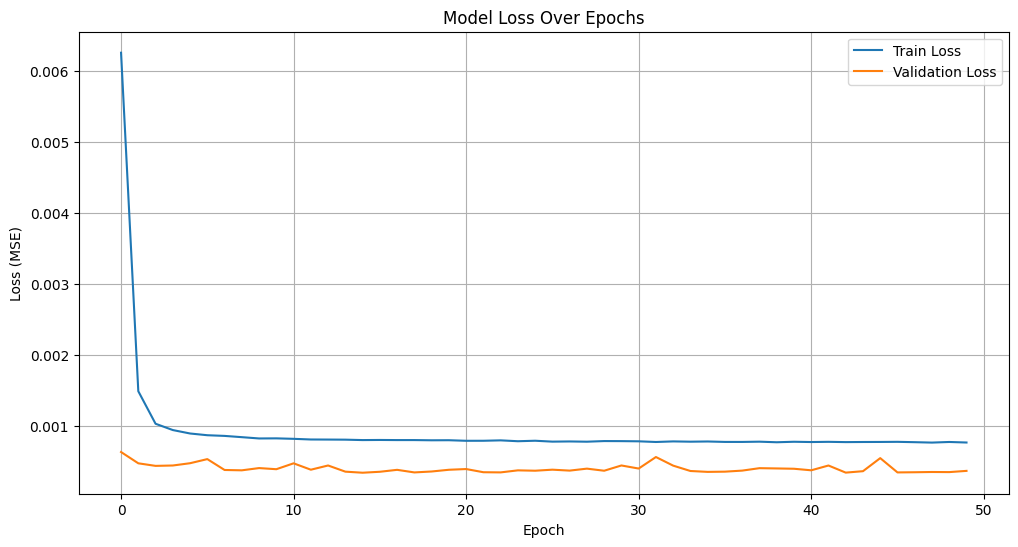

In [39]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Part C: Model Evaluation & Forecasting

6. Evaluate the model on the test set:
○ Calculate RMSE, MAE, and R2 score.
○ Plot predicted vs actual temperatures for the test period.
7. Forecast the next 7 days of temperature using the trained model and visualize
predictions vs recent historical data.

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_scaled = model.predict(X_test_split)

# The target variable is 'Temperature (C)' which is at target_index=0 in numerical_cols.
# We need to inverse transform the scaled predictions and actual values.

# Create dummy arrays for inverse transformation, as scaler expects a 2D array with all features
# We will use the last known values for Humidity and Wind Speed for inverse transformation,
# as they are not being predicted and only temperature is. This is a simplification
# for visualization purposes, the actual metrics are calculated on the scaled data.

# For y_test_split:
dummy_y_test = np.zeros((len(y_test_split), len(numerical_cols)))
dummy_y_test[:, target_index] = y_test_split
y_test_actual = scaler.inverse_transform(dummy_y_test)[:, target_index]

# For y_pred_scaled:
dummy_y_pred = np.zeros((len(y_pred_scaled), len(numerical_cols)))
dummy_y_pred[:, target_index] = y_pred_scaled.flatten() # Flatten since predict returns 2D (samples, 1)
y_pred_actual = scaler.inverse_transform(dummy_y_pred)[:, target_index]

# Calculate evaluation metrics (using inverse transformed values for better interpretability)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2) Score: {r2:.4f}')

302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Root Mean Squared Error (RMSE): 0.0182
Mean Absolute Error (MAE): 0.0124
R-squared (R2) Score: 0.9843


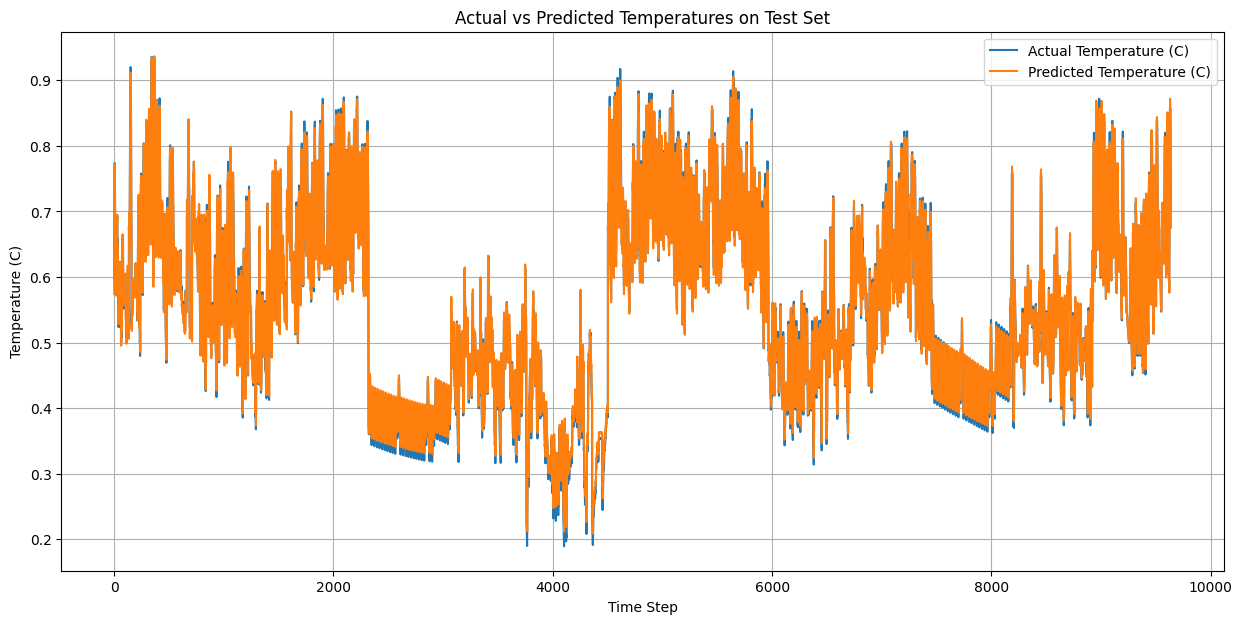

In [42]:
import matplotlib.pyplot as plt

# Plot predicted vs actual temperatures for the test period
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual, label='Actual Temperature (C)')
plt.plot(y_pred_actual, label='Predicted Temperature (C)')
plt.title('Actual vs Predicted Temperatures on Test Set')
plt.xlabel('Time Step')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Forecasted next 7 days temperatures (C):
Day 1: 0.65 C
Day 2: 0.62 C
Day 3: 0.60 C
Day 4: 0.57 C
Day 5: 0.56 C
Day 6: 0.55 C
Day 7: 0.53 C


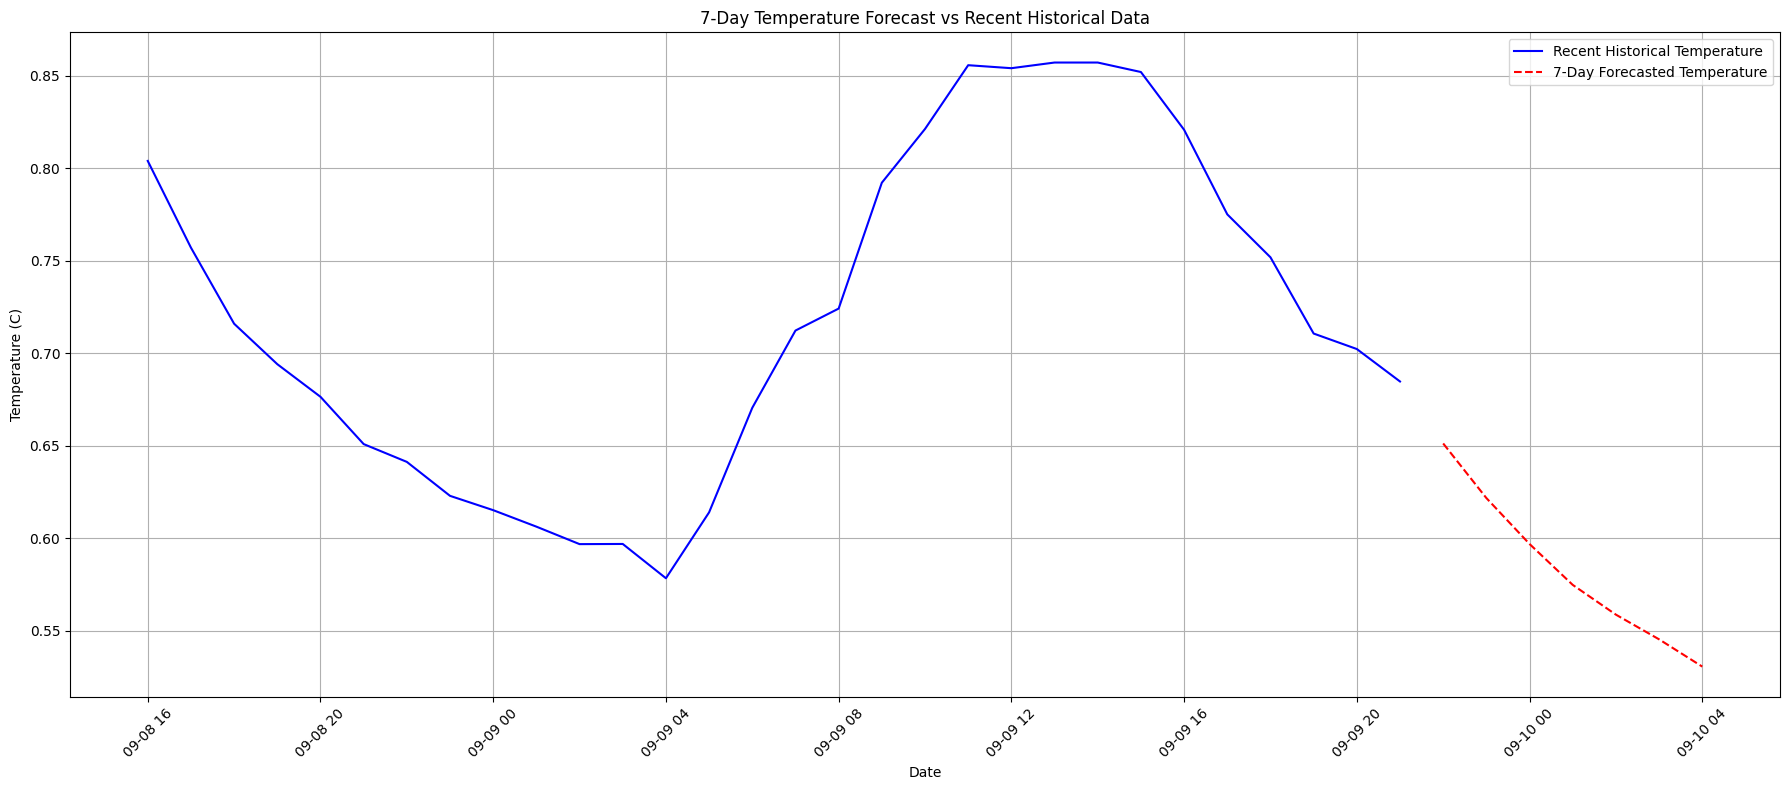

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get the last 'sequence_length' data points from the full scaled dataset
# This will be our starting point for forecasting
last_sequence = full_scaled_data[-sequence_length:]

# Initialize a list to store forecasted temperatures
forecasted_temperatures_scaled = []

# Use the model to forecast the next 7 days
current_sequence = last_sequence.copy()

for _ in range(7): # Forecast for 7 days
    # Reshape the current_sequence to be (1, sequence_length, num_features) for model prediction
    input_for_prediction = current_sequence.reshape(1, sequence_length, len(numerical_cols))

    # Predict the next day's temperature (scaled)
    next_temp_scaled = model.predict(input_for_prediction)[0, 0]
    forecasted_temperatures_scaled.append(next_temp_scaled)

    # Create a dummy array to inverse transform the single forecasted temperature
    dummy_forecast_temp = np.zeros((1, len(numerical_cols)))
    dummy_forecast_temp[0, target_index] = next_temp_scaled

    # Append the predicted temperature to the sequence and remove the oldest data point
    # For simplicity, we'll assume other features (humidity, wind speed) remain constant
    # or use their last known values for the forecast sequence.
    # In a real-world scenario, these would also need to be forecasted or external data used.
    new_row = current_sequence[-1, :].copy() # Start with the features of the last known day
    new_row[target_index] = next_temp_scaled # Update only the temperature with the predicted value

    current_sequence = np.vstack([current_sequence[1:], new_row])

# Inverse transform the forecasted temperatures to original scale
dummy_forecasts = np.zeros((len(forecasted_temperatures_scaled), len(numerical_cols)))
dummy_forecasts[:, target_index] = np.array(forecasted_temperatures_scaled)
forecasted_temperatures_actual = scaler.inverse_transform(dummy_forecasts)[:, target_index]

print("Forecasted next 7 days temperatures (C):")
for i, temp in enumerate(forecasted_temperatures_actual):
    print(f"Day {i+1}: {temp:.2f} C")

# Visualize predictions vs recent historical data

# Get recent historical data (e.g., last 30 days before forecast)
recent_historical_data_count = 30 # Number of days to show historically
recent_historical_data_actual = scaler.inverse_transform(full_scaled_data[-recent_historical_data_count:])[:, target_index]

# Create date range for plotting
last_date_str = train_ds['Formatted Date'].iloc[-1]
last_date = pd.to_datetime(last_date_str)

historical_dates = pd.date_range(end=last_date, periods=recent_historical_data_count, freq='h') # Assuming hourly data
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=7, freq='h') # Assuming hourly forecast

plt.figure(figsize=(18, 8))
plt.plot(historical_dates, recent_historical_data_actual, label='Recent Historical Temperature', color='blue')
plt.plot(forecast_dates, forecasted_temperatures_actual, label='7-Day Forecasted Temperature', color='red', linestyle='--')
plt.title('7-Day Temperature Forecast vs Recent Historical Data')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()